# 02 — Tabu Search aplicado al ATSP

**Variante del TSP — Notebook 2 de 5**

Tabu Search mantiene una única solución y usa memoria de corto plazo para evitar
volver inmediatamente a movimientos recientes. En el ATSP se utiliza un
vecindario de **intercambio de dos ciudades**; repetir el mismo intercambio
restauraría la solución anterior, por lo que ese par de ciudades se registra
como atributo tabú.

## Qué se aprenderá
1. Memoria tabú, aspiración y movimientos no mejorantes.
2. Adaptación del vecindario a costos dirigidos.
3. Muestreo del vecindario para controlar el costo con 50 y 100 ciudades.
4. Comparación para entradas de 10, 20, 50 y 100 ciudades.

## Semillas dinámicas de esta versión
- `MASTER_SEED = None` genera una variante nueva cada vez que se ejecuta todo.
- Cada tamaño utiliza semillas independientes y estas se imprimen antes de resolverlo.
- Para repetir una ejecución, copia la semilla maestra impresa y colócala en `MASTER_SEED`.


## 1. Variante estudiada: TSP asimétrico (ATSP)

En el TSP tradicional suele suponerse que la distancia es simétrica:

$$c_{ij}=c_{ji}.$$

En el **Asymmetric Traveling Salesman Problem (ATSP)** esta igualdad no se exige:

$$c_{ij}\neq c_{ji}.$$

Esto representa situaciones reales como calles de un solo sentido, pendientes,
peajes diferentes, viento, congestión o tiempos de viaje dependientes de la
dirección. Se busca una permutación de todas las ciudades que minimice

$$f(\pi)=\sum_{k=0}^{n-1}c_{\pi_k,\pi_{(k+1)\bmod n}}.$$

Los tres tamaños usados son **10, 20, 50 y 100 ciudades**. En cada ejecución se crea una **semilla maestra nueva** y, a partir de ella,
semillas independientes para las instancias y los componentes aleatorios. Todas
se imprimen y se guardan en las tablas. Para repetir un resultado basta con copiar
la semilla maestra mostrada y asignarla a `MASTER_SEED`.


In [ ]:
%matplotlib inline
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def make_atsp_instance(n, seed=42, asymmetry=0.40):
    """Crea coordenadas y una matriz de costos dirigida para un ATSP."""
    rng = np.random.default_rng(seed)
    coords = rng.uniform(0, 100, size=(n, 2))
    delta = coords[:, None, :] - coords[None, :, :]
    euclidean = np.sqrt((delta ** 2).sum(axis=2))
    directional_factor = 1.0 + asymmetry * rng.uniform(-1.0, 1.0, size=(n, n))
    D = euclidean * directional_factor
    np.fill_diagonal(D, np.inf)
    return coords, D


def tour_cost(tour, D):
    tour = np.asarray(tour, dtype=int)
    return float(D[tour, np.roll(tour, -1)].sum())


def validate_tour(tour, n):
    tour = np.asarray(tour, dtype=int)
    return len(tour) == n and np.array_equal(np.sort(tour), np.arange(n))


def nearest_neighbor(D, start=0):
    """Solución inicial rápida respetando los costos dirigidos."""
    n = len(D)
    unvisited = set(range(n))
    unvisited.remove(start)
    tour = [start]
    while unvisited:
        last = tour[-1]
        nxt = min(unvisited, key=lambda j: D[last, j])
        tour.append(nxt)
        unvisited.remove(nxt)
    return np.asarray(tour, dtype=int)


def random_tour(n, rng):
    """Fija la ciudad 0 al comienzo para eliminar rotaciones equivalentes."""
    return np.r_[0, rng.permutation(np.arange(1, n))]


def asymmetry_index(D):
    """Promedio relativo de |c_ij-c_ji| sobre los arcos fuera de la diagonal."""
    n = len(D)
    mask = ~np.eye(n, dtype=bool)
    forward = D[mask]
    reverse = D.T[mask]
    denom = np.maximum((forward + reverse) / 2.0, 1e-12)
    return float(np.mean(np.abs(forward - reverse) / denom))


def plot_directed_tour(coords, tour, title='', ax=None):
    """Dibuja el ciclo e indica su orientación con flechas."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))
    tour = np.asarray(tour, dtype=int)
    closed = np.r_[tour, tour[0]]
    xy = coords[closed]
    ax.plot(xy[:, 0], xy[:, 1], '-o', linewidth=1.3, markersize=4)
    dx = xy[1:, 0] - xy[:-1, 0]
    dy = xy[1:, 1] - xy[:-1, 1]
    ax.quiver(xy[:-1, 0], xy[:-1, 1], dx, dy,
              angles='xy', scale_units='xy', scale=1,
              width=0.003, alpha=0.65)
    if len(coords) <= 20:
        for i, (x, y) in enumerate(coords):
            ax.annotate(str(i), (x, y), xytext=(4, 4),
                        textcoords='offset points', fontsize=8)
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.2)
    return ax

MASTER_SEED = None

if MASTER_SEED is None:
    RUN_SEED = int(np.random.SeedSequence().generate_state(1, dtype=np.uint32)[0])
else:
    RUN_SEED = int(MASTER_SEED)

seed_rng = np.random.default_rng(RUN_SEED)
SIZES = [10, 20, 50, 100]


def next_seed():
    """Entrega una semilla uint32 independiente y compatible con NumPy."""
    return int(seed_rng.integers(0, 2**32, dtype=np.uint32))


INSTANCE_SEEDS = {n: next_seed() for n in SIZES}
START_SEEDS = {n: next_seed() for n in SIZES}
TEMPERATURE_SEEDS = {n: next_seed() for n in SIZES}
ALGORITHM_SEEDS = {n: next_seed() for n in SIZES}

INSTANCES = {
    n: make_atsp_instance(n, seed=INSTANCE_SEEDS[n], asymmetry=0.40)
    for n in SIZES
}

seed_table = pd.DataFrame({
    'n': SIZES,
    'semilla_instancia': [INSTANCE_SEEDS[n] for n in SIZES],
    'semilla_inicio': [START_SEEDS[n] for n in SIZES],
    'semilla_temperatura': [TEMPERATURE_SEEDS[n] for n in SIZES],
    'semilla_algoritmo': [ALGORITHM_SEEDS[n] for n in SIZES],
})

print('=' * 72)
print(f'SEMILLA MAESTRA DE ESTA EJECUCIÓN: {RUN_SEED}')
print('Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.')
print('=' * 72)
display(seed_table)

for n, (_, D) in INSTANCES.items():
    print(
        f'n={n:3d} | semilla instancia={INSTANCE_SEEDS[n]:10d} | '
        f'asimetría={asymmetry_index(D):.3f} | '
        f'costo greedy={tour_cost(nearest_neighbor(D), D):.2f}'
    )


SEMILLA MAESTRA DE ESTA EJECUCIÓN: 1248055171
Para repetirla, asigna ese número a MASTER_SEED y ejecuta todo nuevamente.


,n,semilla_instancia,semilla_inicio,semilla_temperatura,semilla_algoritmo
0,10,687053063,3863575146,1093361920,1876218772
1,20,559017167,1185721926,2422189709,2341415110
2,50,385311663,138553523,1725930508,1788375770
3,100,1733912635,2287416756,1073896520,1858129999


n= 10 | semilla instancia= 687053063 | asimetría=0.277 | costo greedy=404.28
n= 20 | semilla instancia= 559017167 | asimetría=0.272 | costo greedy=564.88
n= 50 | semilla instancia= 385311663 | asimetría=0.279 | costo greedy=633.24
n=100 | semilla instancia=1733912635 | asimetría=0.265 | costo greedy=891.00


## 2. Motor genérico de Tabu Search

En cada iteración se selecciona el mejor vecino admisible. Un movimiento tabú
puede aceptarse mediante **aspiración** cuando mejora el mejor resultado global.
Para `n=50` y `n=100` no es obligatorio revisar todos los intercambios: se puede tomar una
muestra reproducible del vecindario.


In [ ]:
def tabu_search(initial, neighbors, cost, tenure=10, max_iter=150, seed=0):
    """Tabu Search genérico para minimización."""
    rng = np.random.default_rng(seed)
    current = initial.copy()
    current_cost = cost(current)
    best = current.copy()
    best_cost = current_cost
    tabu_until = {}
    history = [best_cost]

    for iteration in range(max_iter):
        candidates = neighbors(current, rng)
        chosen = None
        chosen_attr = None
        chosen_cost = np.inf

        for attr, solution in candidates:
            value = cost(solution)
            is_tabu = tabu_until.get(attr, -1) > iteration
            aspiration = value < best_cost - 1e-12
            if is_tabu and not aspiration:
                continue
            if value < chosen_cost:
                chosen = solution
                chosen_attr = attr
                chosen_cost = value

        if chosen is None:
            chosen_attr, chosen = min(candidates, key=lambda item: cost(item[1]))
            chosen_cost = cost(chosen)

        current = chosen
        current_cost = chosen_cost
        tabu_until[chosen_attr] = iteration + tenure

        if current_cost < best_cost:
            best = current.copy()
            best_cost = current_cost
        history.append(best_cost)

    return best, best_cost, history


def make_swap_neighborhood(n, max_neighbors=None):
    """Crea una función de vecindario que conserva la ciudad 0 en la posición 0."""
    all_pairs = [(i, j) for i in range(1, n - 1) for j in range(i + 1, n)]

    def neighbors(tour, rng):
        if max_neighbors is None or len(all_pairs) <= max_neighbors:
            pairs = all_pairs
        else:
            idx = rng.choice(len(all_pairs), size=max_neighbors, replace=False)
            pairs = [all_pairs[k] for k in idx]

        output = []
        for i, j in pairs:
            new = tour.copy()
            city_i, city_j = int(new[i]), int(new[j])
            new[i], new[j] = new[j], new[i]
            attr = tuple(sorted((city_i, city_j)))
            output.append((attr, new))
        return output

    return neighbors


## 3. Ejemplo principal: 20 ciudades

Semilla maestra   : 1248055171
Semilla instancia : 559017167
Semilla algoritmo : 2341415110
Costo inicial : 564.878
Mejor costo   : 402.852
Mejora        : 28.68%
Ruta válida   : True


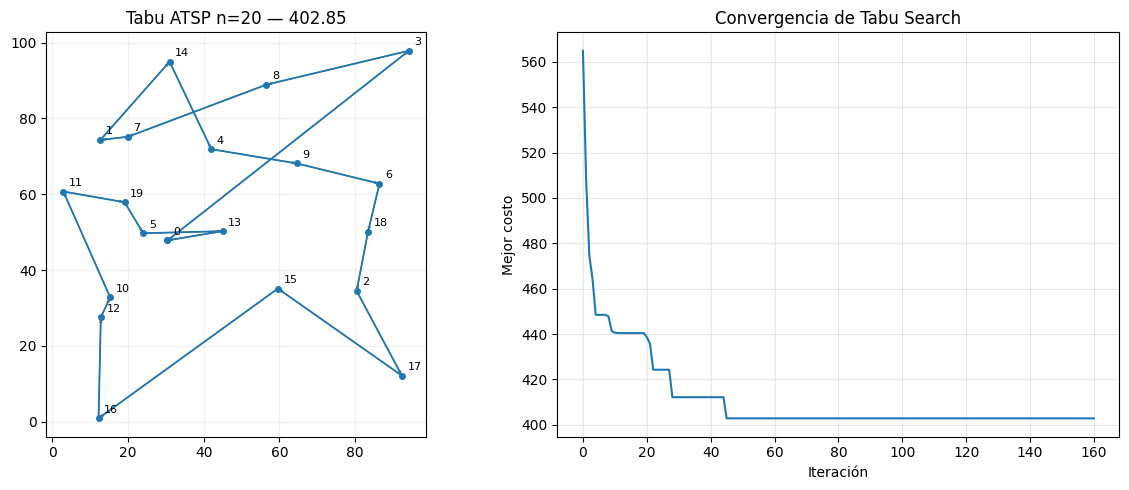

In [3]:
coords20, D20 = INSTANCES[20]
start20 = nearest_neighbor(D20)
cost20 = lambda tour: tour_cost(tour, D20)
neighbors20 = make_swap_neighborhood(20)
seed20 = ALGORITHM_SEEDS[20]

print(f'Semilla maestra   : {RUN_SEED}')
print(f'Semilla instancia : {INSTANCE_SEEDS[20]}')
print(f'Semilla algoritmo : {seed20}')

best20, value20, history20 = tabu_search(
    start20, neighbors20, cost20,
    tenure=9, max_iter=160, seed=seed20
)

print(f'Costo inicial : {cost20(start20):.3f}')
print(f'Mejor costo   : {value20:.3f}')
print(f'Mejora        : {100 * (cost20(start20)-value20)/cost20(start20):.2f}%')
print(f'Ruta válida   : {validate_tour(best20, 20)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_directed_tour(coords20, best20, f'Tabu ATSP n=20 — {value20:.2f}', ax=axes[0])
axes[1].plot(history20)
axes[1].set_title('Convergencia de Tabu Search')
axes[1].set_xlabel('Iteración')
axes[1].set_ylabel('Mejor costo')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Entradas de 10, 20, 50 y 100 ciudades

In [ ]:
TABU_CONFIG = {
    10: {'tenure': 6, 'iterations': 120, 'max_neighbors': None},
    20: {'tenure': 9, 'iterations': 160, 'max_neighbors': None},
    50: {'tenure': 14, 'iterations': 200, 'max_neighbors': 400},
    100: {'tenure': 20, 'iterations': 250, 'max_neighbors': 600},
}

tabu_results = []
tabu_histories = {}
tabu_solutions = {}

for execution_id, n in enumerate(SIZES, start=1):
    coords, D = INSTANCES[n]
    cfg = TABU_CONFIG[n]
    algorithm_seed = ALGORITHM_SEEDS[n]
    start = nearest_neighbor(D)
    cost_fn = lambda tour, D=D: tour_cost(tour, D)
    neighborhood = make_swap_neighborhood(n, cfg['max_neighbors'])

    print('\n' + '-' * 72)
    print(f'Ejecución {execution_id}/{len(SIZES)} — Tabu Search — n={n}')
    print(f'Semilla de instancia : {INSTANCE_SEEDS[n]}')
    print(f'Semilla de algoritmo : {algorithm_seed}')

    t0 = time.perf_counter()
    best, value, history = tabu_search(
        start, neighborhood, cost_fn,
        tenure=cfg['tenure'],
        max_iter=cfg['iterations'],
        seed=algorithm_seed,
    )
    elapsed = time.perf_counter() - t0

    tabu_solutions[n] = best
    tabu_histories[n] = history
    baseline = cost_fn(start)
    tabu_results.append({
        'ejecucion': execution_id,
        'n': n,
        'semilla_maestra': RUN_SEED,
        'semilla_instancia': INSTANCE_SEEDS[n],
        'semilla_algoritmo': algorithm_seed,
        'costo_inicial': baseline,
        'mejor_costo': value,
        'mejora_%': 100 * (baseline - value) / baseline,
        'iteraciones': cfg['iterations'],
        'vecinos_por_iter': cfg['max_neighbors'] or math.comb(n - 1, 2),
        'tiempo_s': elapsed,
    })

    print(f'Mejor costo          : {value:.3f}')
    print(f'Tiempo               : {elapsed:.3f} s')


tabu_df = pd.DataFrame(tabu_results)
display(tabu_df.round({
    'costo_inicial': 2,
    'mejor_costo': 2,
    'mejora_%': 2,
    'tiempo_s': 3,
}))


------------------------------------------------------------------------
Ejecución 1/4 — Tabu Search — n=10
Semilla de instancia : 687053063
Semilla de algoritmo : 1876218772
Mejor costo          : 293.743
Tiempo               : 0.543 s

------------------------------------------------------------------------
Ejecución 2/4 — Tabu Search — n=20
Semilla de instancia : 559017167
Semilla de algoritmo : 2341415110
Mejor costo          : 402.852
Tiempo               : 3.397 s

------------------------------------------------------------------------
Ejecución 3/4 — Tabu Search — n=50
Semilla de instancia : 385311663
Semilla de algoritmo : 1788375770
Mejor costo          : 610.452
Tiempo               : 4.787 s

------------------------------------------------------------------------
Ejecución 4/4 — Tabu Search — n=100
Semilla de instancia : 1733912635
Semilla de algoritmo : 1858129999
Mejor costo          : 816.569
Tiempo               : 7.639 s


,ejecucion,n,semilla_maestra,semilla_instancia,semilla_algoritmo,costo_inicial,mejor_costo,mejora_%,iteraciones,vecinos_por_iter,tiempo_s
0,1,10,1248055171,687053063,1876218772,404.28,293.74,27.34,120,36,0.543
1,2,20,1248055171,559017167,2341415110,564.88,402.85,28.68,160,171,3.397
2,3,50,1248055171,385311663,1788375770,633.24,610.45,3.60,200,400,4.787
3,4,100,1248055171,1733912635,1858129999,891.00,816.57,8.35,250,600,7.639


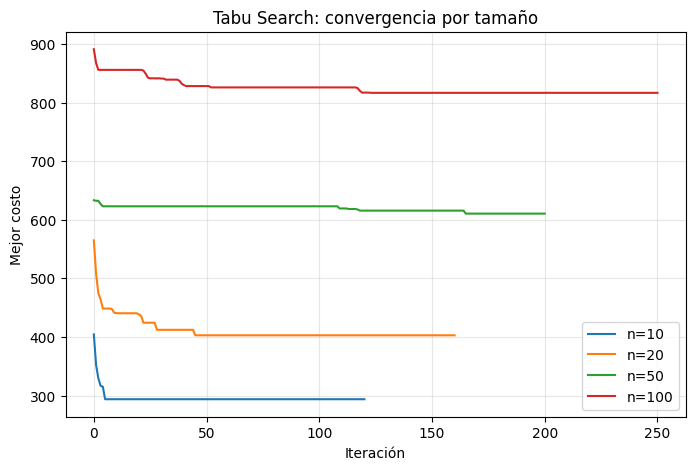

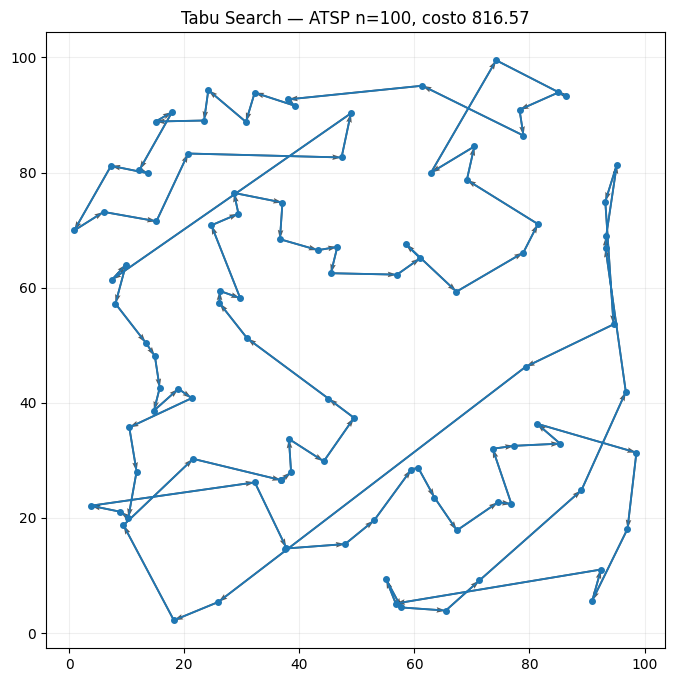

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
for n in SIZES:
    ax.plot(tabu_histories[n], label=f'n={n}')
ax.set_title('Tabu Search: convergencia por tamaño')
ax.set_xlabel('Iteración')
ax.set_ylabel('Mejor costo')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

coords100, D100 = INSTANCES[100]
fig, ax = plt.subplots(figsize=(8, 8))
plot_directed_tour(
    coords100,
    tabu_solutions[100],
    f'Tabu Search — ATSP n=100, costo {tour_cost(tabu_solutions[100], D100):.2f}',
    ax=ax,
)
plt.show()


## 5. Parámetros, trade-offs y complejidad

- Una iteración completa con intercambio de posiciones evalúa
  $\binom{n-1}{2}=O(n^2)$ vecinos.
- La tenencia corta favorece intensificación, pero puede producir ciclos.
- La tenencia larga aumenta diversificación, aunque puede bloquear movimientos
  útiles.
- Muestrear vecinos reduce tiempo y puede perder el mejor movimiento local.
- La aspiración evita que la memoria impida una mejora global.

## Ejercicios
1. Comparar intercambio, inserción y reversión de segmentos.
2. Hacer la tenencia aleatoria dentro de un rango.
3. Implementar evaluación incremental del costo del intercambio.
4. Ejecutar varias semillas y reportar promedio y desviación estándar.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def crear_gantt_ruta(
    ruta,
    D,
    algoritmo,
    n,
    semilla_instancia,
    semilla_algoritmo=None,
    semillas_adicionales=None,
    guardar=False,
    nombre_archivo=None,
    mostrar_tabla=True
):
   

    ruta = np.asarray(ruta, dtype=int)
    D = np.asarray(D, dtype=float)

    if ruta.ndim != 1:
        raise ValueError("La ruta debe ser un arreglo unidimensional.")

    if len(ruta) != n:
        raise ValueError(
            f"La ruta tiene {len(ruta)} ciudades, pero se esperaba n={n}."
        )

    if len(np.unique(ruta)) != n:
        raise ValueError(
            "La ruta contiene ciudades repetidas."
        )

    if not np.array_equal(np.sort(ruta), np.arange(n)):
        raise ValueError(
            "La ruta no contiene exactamente las ciudades entre 0 y n-1."
        )

    if D.shape != (n, n):
        raise ValueError(
            f"La matriz D debe tener dimensiones ({n}, {n})."
        )

    ruta_cerrada = np.append(ruta, ruta[0])

    origenes = ruta_cerrada[:-1]
    destinos = ruta_cerrada[1:]

    costos_tramos = np.array([
        D[origen, destino]
        for origen, destino in zip(origenes, destinos)
    ])

    if not np.all(np.isfinite(costos_tramos)):
        raise ValueError(
            "La ruta contiene desplazamientos con costo infinito."
        )

    inicio_acumulado = np.concatenate([
        [0.0],
        np.cumsum(costos_tramos)[:-1]
    ])

    costo_acumulado = np.cumsum(costos_tramos)
    costo_total = float(costo_acumulado[-1])

    percentil_75 = float(
        np.percentile(costos_tramos, 75)
    )

    df_gantt = pd.DataFrame({
        "paso": np.arange(1, n + 1),
        "origen": origenes,
        "destino": destinos,
        "tramo": [
            f"{paso:03d}. Ciudad {origen} → Ciudad {destino}"
            for paso, origen, destino in zip(
                np.arange(1, n + 1),
                origenes,
                destinos
            )
        ],
        "inicio_acumulado": inicio_acumulado,
        "costo_tramo": costos_tramos,
        "costo_acumulado": costo_acumulado,
        "porcentaje_total": (
            costos_tramos / costo_total
        ) * 100,
        "tramo_costoso": (
            costos_tramos >= percentil_75
        )
    })

    altura = max(
        7,
        min(34, 4 + n * 0.29)
    )

    fig, ax = plt.subplots(
        figsize=(17, altura)
    )

    posiciones_y = np.arange(n)

    barras = ax.barh(
        posiciones_y,
        df_gantt["costo_tramo"],
        left=df_gantt["inicio_acumulado"],
        edgecolor="black",
        linewidth=0.7
    )

    for indice, barra in enumerate(barras):

        es_costoso = bool(
            df_gantt.loc[indice, "tramo_costoso"]
        )

        if es_costoso:
            barra.set_hatch("////")
            barra.set_linewidth(1.3)

        costo = float(
            df_gantt.loc[indice, "costo_tramo"]
        )

        inicio = float(
            df_gantt.loc[
                indice,
                "inicio_acumulado"
            ]
        )

        mostrar_valor = (
            n <= 20
            or es_costoso
        )

        if mostrar_valor:
            ax.text(
                inicio + costo / 2,
                indice,
                f"{costo:.1f}",
                ha="center",
                va="center",
                fontsize=7
            )

    ax.axvline(
        costo_total,
        linestyle="--",
        linewidth=1.6
    )

    ax.set_xlim(
        0,
        costo_total * 1.05
    )

    ax.set_yticks(posiciones_y)

    ax.set_yticklabels(
        df_gantt["tramo"],
        fontsize=7 if n >= 50 else 8
    )

    ax.invert_yaxis()

    ax.set_xlabel(
        "Costo acumulado de la ruta"
    )

    ax.set_ylabel(
        "Secuencia de desplazamientos"
    )

    texto_semillas = (
        f"Semilla instancia: {semilla_instancia}"
    )

    if semilla_algoritmo is not None:
        texto_semillas += (
            f" | Semilla algoritmo: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            texto_semillas += (
                f" | {nombre}: {valor}"
            )

    ax.set_title(
        f"{algoritmo} — Carta Gantt de la mejor ruta ATSP\n"
        f"n={n} | costo total={costo_total:.2f}\n"
        f"{texto_semillas}",
        fontsize=13,
        pad=14
    )

    ax.grid(
        axis="x",
        alpha=0.25
    )

    leyenda = [
        Patch(
            fill=False,
            edgecolor="black",
            hatch="////",
            label=(
                f"Tramo costoso ≥ P75 "
                f"({percentil_75:.2f})"
            )
        ),
        Line2D(
            [0],
            [0],
            linestyle="--",
            label=(
                f"Costo total: "
                f"{costo_total:.2f}"
            )
        )
    ]

    ax.legend(
        handles=leyenda,
        loc="lower right"
    )

    plt.tight_layout()

    if guardar:

        if nombre_archivo is None:
            nombre_normalizado = (
                algoritmo
                .lower()
                .replace(" ", "_")
                .replace("&", "and")
            )

            nombre_archivo = (
                f"gantt_{nombre_normalizado}_n{n}.png"
            )

        fig.savefig(
            nombre_archivo,
            dpi=300,
            bbox_inches="tight"
        )

        print(
            f"Gráfico guardado: {nombre_archivo}"
        )

    print("\n" + "=" * 72)
    print(f"ALGORITMO: {algoritmo}")
    print(f"NÚMERO DE CIUDADES: {n}")
    print(f"SEMILLA DE INSTANCIA: {semilla_instancia}")

    if semilla_algoritmo is not None:
        print(
            f"SEMILLA DE ALGORITMO: "
            f"{semilla_algoritmo}"
        )

    if semillas_adicionales:
        for nombre, valor in semillas_adicionales.items():
            print(
                f"{nombre.upper()}: {valor}"
            )

    print(f"COSTO TOTAL: {costo_total:.3f}")
    print(
        f"COSTO PROMEDIO POR TRAMO: "
        f"{costos_tramos.mean():.3f}"
    )
    print(
        f"TRAMO DE MAYOR COSTO: "
        f"{costos_tramos.max():.3f}"
    )
    print(
        f"PERCENTIL 75: "
        f"{percentil_75:.3f}"
    )

    print("\nRuta encontrada:")
    print(
        " → ".join(
            map(str, ruta_cerrada)
        )
    )

    if mostrar_tabla:

        columnas = [
            "paso",
            "origen",
            "destino",
            "costo_tramo",
            "costo_acumulado",
            "porcentaje_total",
            "tramo_costoso"
        ]

        display(
            df_gantt[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

        print("\nCinco tramos de mayor costo:")

        display(
            df_gantt.nlargest(
                5,
                "costo_tramo"
            )[columnas].round({
                "costo_tramo": 3,
                "costo_acumulado": 3,
                "porcentaje_total": 2
            })
        )

    return df_gantt, fig, ax


################################################################################
CARTA GANTT TABU SEARCH — n=10
Semilla instancia: 687053063
Semilla algoritmo: 1876218772
Gráfico guardado: gantt_tabu_search_n10_instance_seed_687053063_algorithm_seed_1876218772.png

ALGORITMO: Tabu Search
NÚMERO DE CIUDADES: 10
SEMILLA DE INSTANCIA: 687053063
SEMILLA DE ALGORITMO: 1876218772
COSTO TOTAL: 293.743
COSTO PROMEDIO POR TRAMO: 29.374
TRAMO DE MAYOR COSTO: 76.428
PERCENTIL 75: 43.265

Ruta encontrada:
0 → 5 → 2 → 9 → 3 → 6 → 8 → 1 → 7 → 4 → 0


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,5,12.359,12.359,4.21,False
1,2,5,2,30.823,43.182,10.49,False
2,3,2,9,8.989,52.171,3.06,False
3,4,9,3,44.712,96.883,15.22,True
4,5,3,6,76.428,173.311,26.02,True
5,6,6,8,38.922,212.234,13.25,False
6,7,8,1,2.493,214.727,0.85,False
7,8,1,7,13.433,228.160,4.57,False
8,9,7,4,11.314,239.474,3.85,False
9,10,4,0,54.269,293.743,18.47,True



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
4,5,3,6,76.428,173.311,26.02,True
9,10,4,0,54.269,293.743,18.47,True
3,4,9,3,44.712,96.883,15.22,True
5,6,6,8,38.922,212.234,13.25,False
1,2,5,2,30.823,43.182,10.49,False


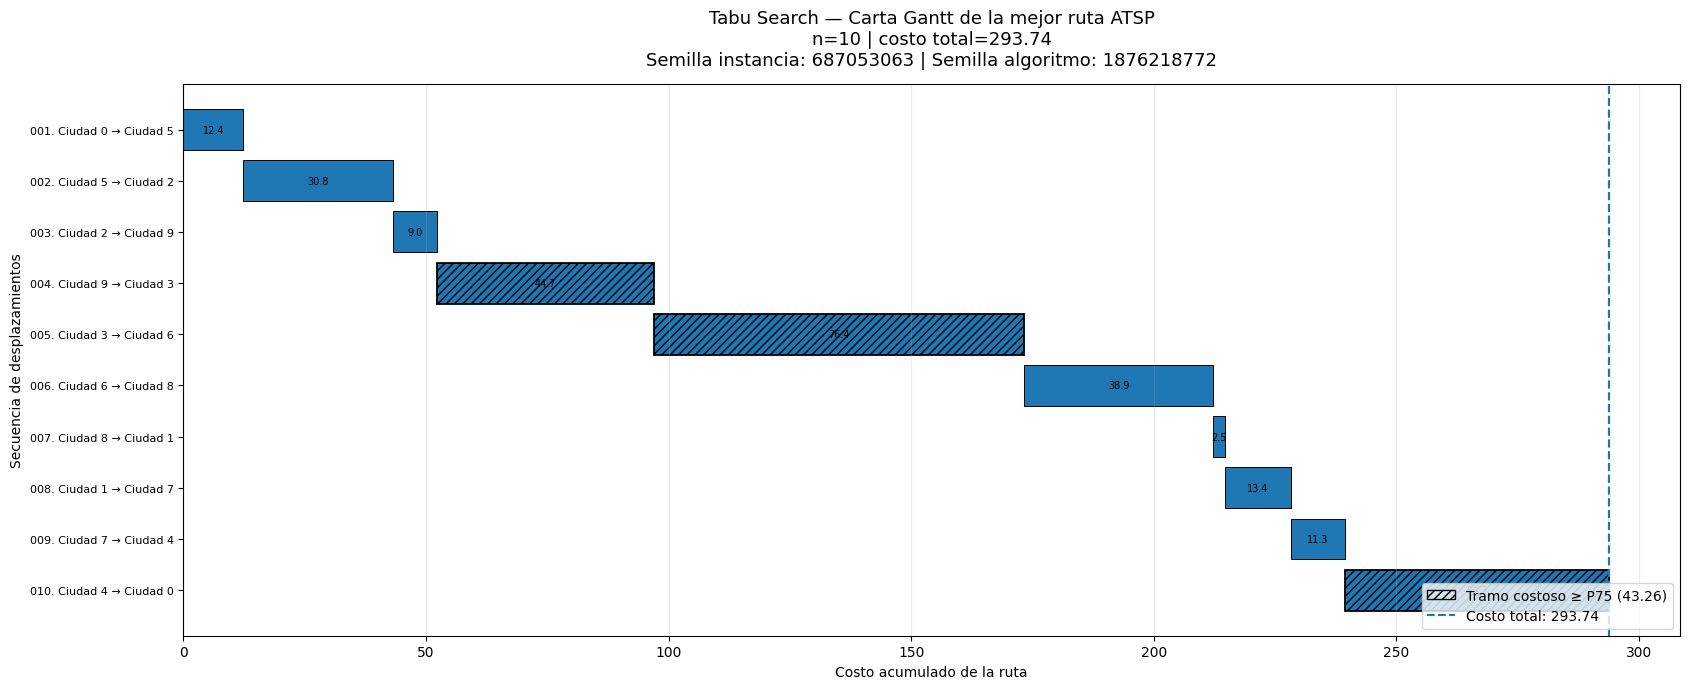


################################################################################
CARTA GANTT TABU SEARCH — n=20
Semilla instancia: 559017167
Semilla algoritmo: 2341415110
Gráfico guardado: gantt_tabu_search_n20_instance_seed_559017167_algorithm_seed_2341415110.png

ALGORITMO: Tabu Search
NÚMERO DE CIUDADES: 20
SEMILLA DE INSTANCIA: 559017167
SEMILLA DE ALGORITMO: 2341415110
COSTO TOTAL: 402.852
COSTO PROMEDIO POR TRAMO: 20.143
TRAMO DE MAYOR COSTO: 48.962
PERCENTIL 75: 27.186

Ruta encontrada:
0 → 3 → 8 → 7 → 1 → 14 → 4 → 9 → 6 → 18 → 2 → 17 → 15 → 16 → 12 → 10 → 11 → 19 → 5 → 13 → 0


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,3,48.962,48.962,12.15,True
1,2,3,8,29.093,78.055,7.22,True
2,3,8,7,26.934,104.989,6.69,False
3,4,7,1,4.385,109.374,1.09,False
4,5,1,14,18.856,128.230,4.68,False
5,6,14,4,15.559,143.789,3.86,False
6,7,4,9,15.743,159.532,3.91,False
7,8,9,6,19.333,178.865,4.80,False
8,9,6,18,12.368,191.233,3.07,False
9,10,18,2,10.086,201.319,2.50,False



Cinco tramos de mayor costo:


,paso,origen,destino,costo_tramo,costo_acumulado,porcentaje_total,tramo_costoso
0,1,0,3,48.962,48.962,12.15,True
13,14,16,12,36.744,329.256,9.12,True
12,13,15,16,36.479,292.512,9.06,True
1,2,3,8,29.093,78.055,7.22,True
10,11,2,17,27.940,229.259,6.94,True


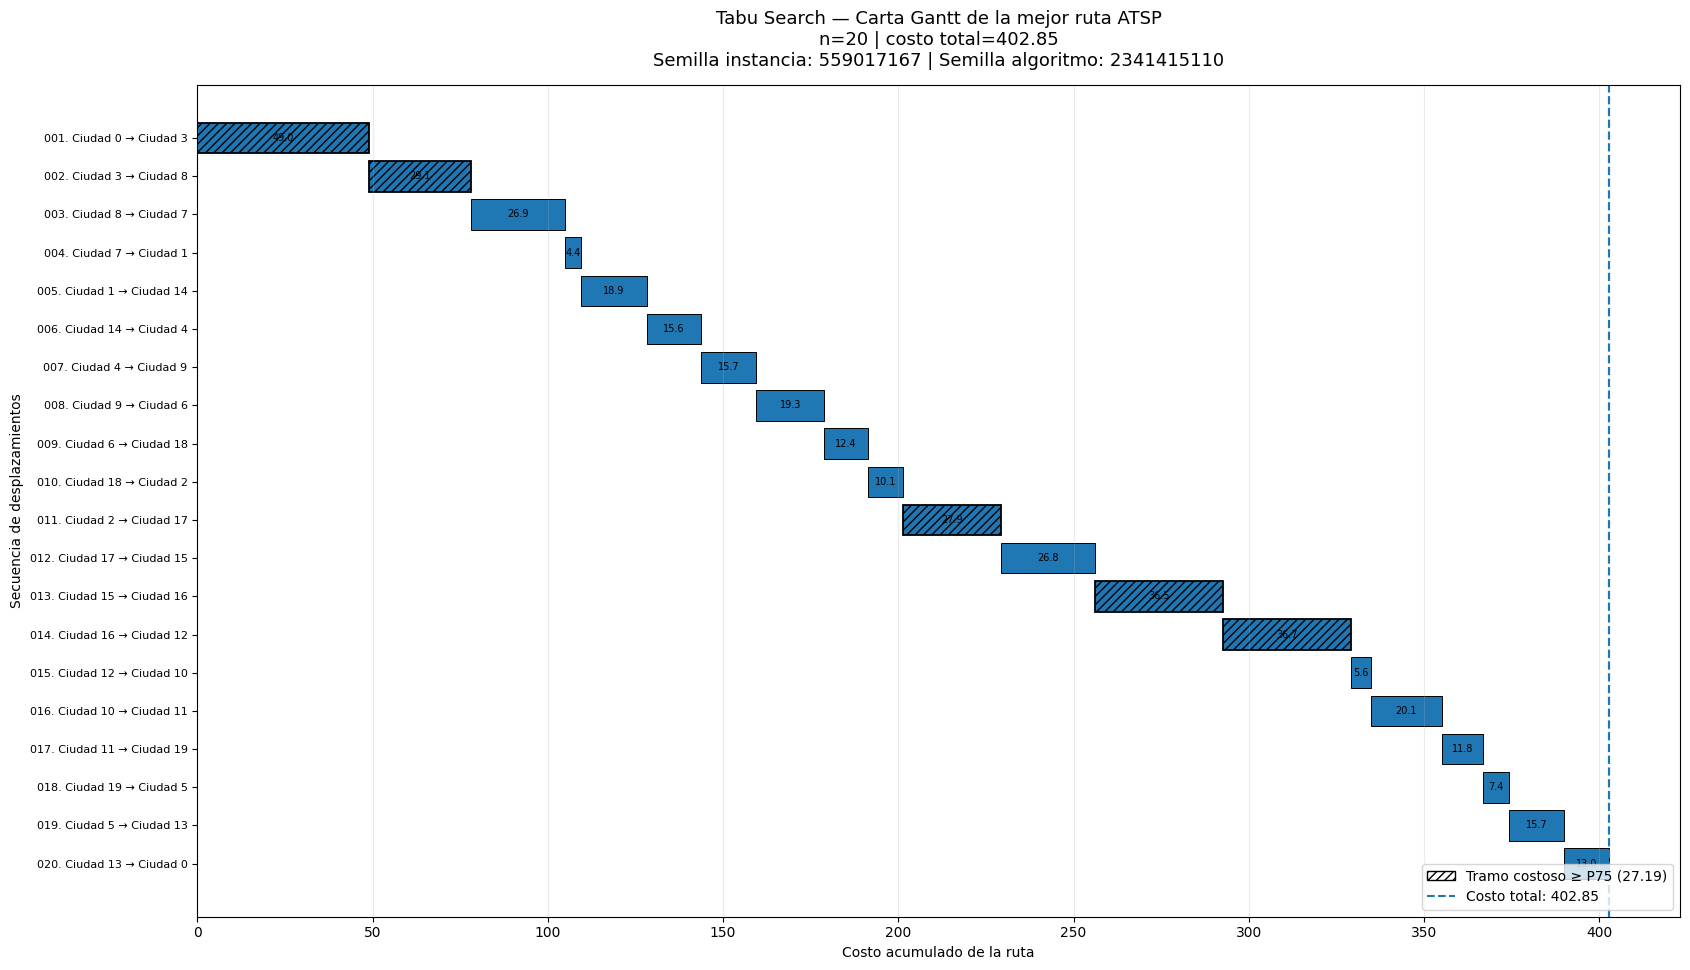


################################################################################
CARTA GANTT TABU SEARCH — n=50
Semilla instancia: 385311663
Semilla algoritmo: 1788375770
Gráfico guardado: gantt_tabu_search_n50_instance_seed_385311663_algorithm_seed_1788375770.png

ALGORITMO: Tabu Search
NÚMERO DE CIUDADES: 50
SEMILLA DE INSTANCIA: 385311663
SEMILLA DE ALGORITMO: 1788375770
COSTO TOTAL: 610.452
COSTO PROMEDIO POR TRAMO: 12.209
TRAMO DE MAYOR COSTO: 60.088
PERCENTIL 75: 14.124

Ruta encontrada:
0 → 17 → 40 → 45 → 28 → 12 → 19 → 33 → 2 → 46 → 23 → 30 → 16 → 5 → 26 → 29 → 27 → 6 → 34 → 48 → 20 → 47 → 38 → 10 → 21 → 9 → 31 → 35 → 32 → 44 → 15 → 25 → 49 → 18 → 4 → 43 → 37 → 39 → 22 → 36 → 7 → 3 → 1 → 42 → 11 → 13 → 14 → 24 → 8 → 41 → 0


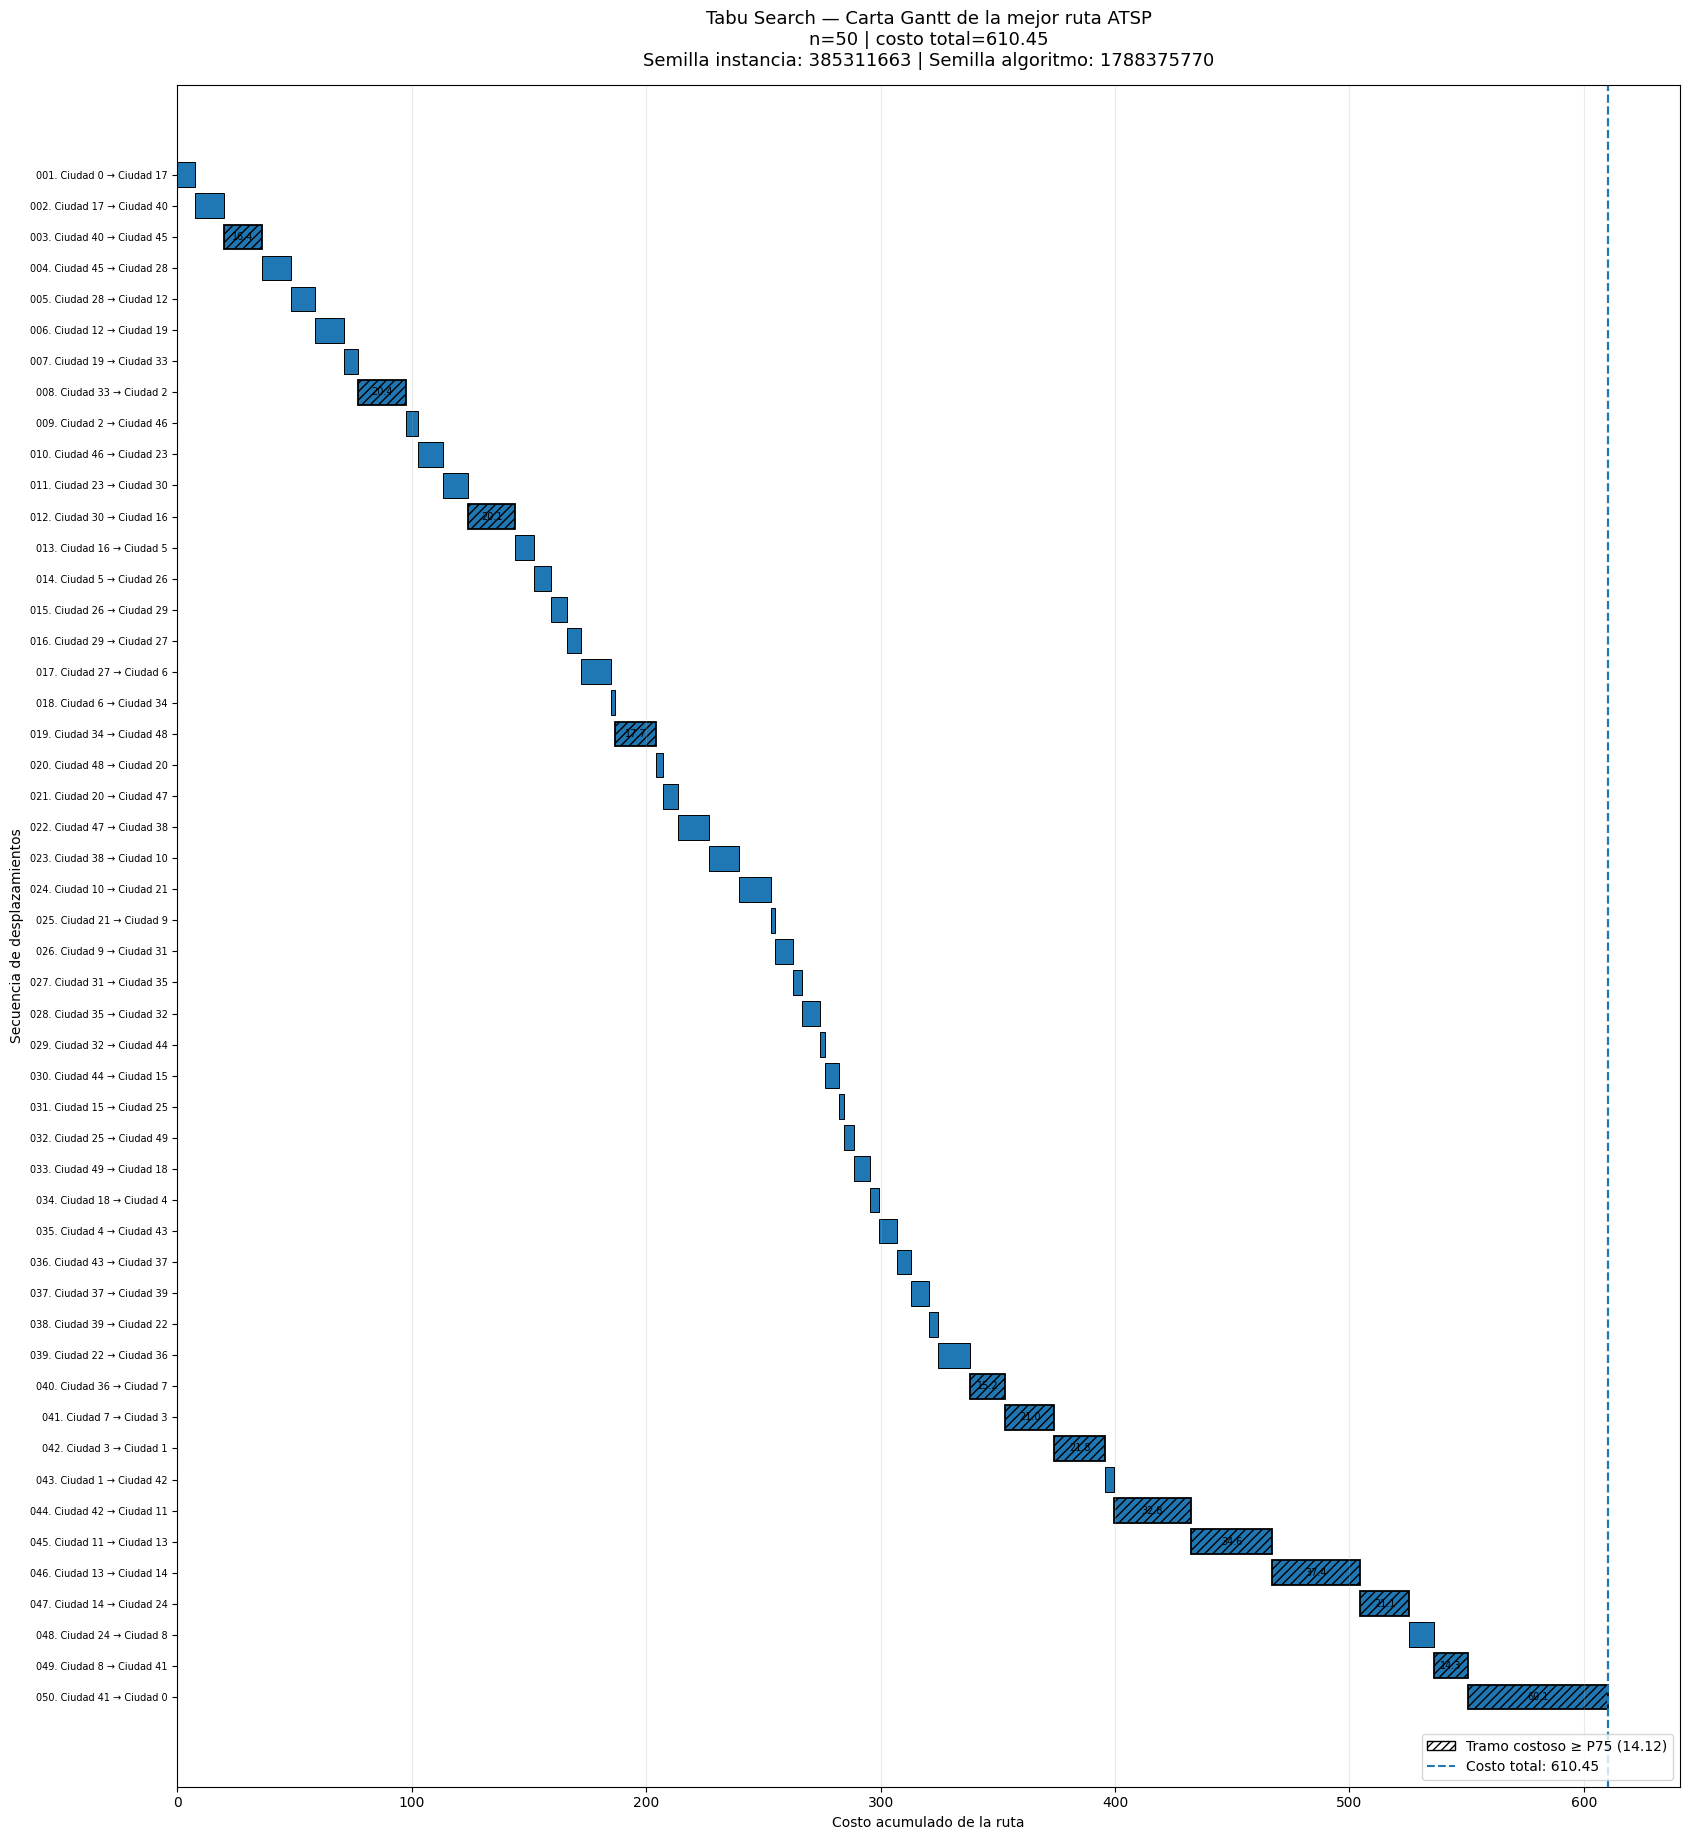


################################################################################
CARTA GANTT TABU SEARCH — n=100
Semilla instancia: 1733912635
Semilla algoritmo: 1858129999
Gráfico guardado: gantt_tabu_search_n100_instance_seed_1733912635_algorithm_seed_1858129999.png

ALGORITMO: Tabu Search
NÚMERO DE CIUDADES: 100
SEMILLA DE INSTANCIA: 1733912635
SEMILLA DE ALGORITMO: 1858129999
COSTO TOTAL: 816.569
COSTO PROMEDIO POR TRAMO: 8.166
TRAMO DE MAYOR COSTO: 55.644
PERCENTIL 75: 10.478

Ruta encontrada:
0 → 60 → 51 → 72 → 1 → 98 → 30 → 22 → 14 → 47 → 18 → 46 → 31 → 7 → 55 → 85 → 39 → 79 → 45 → 75 → 4 → 56 → 83 → 54 → 81 → 17 → 97 → 35 → 88 → 93 → 10 → 20 → 69 → 24 → 94 → 12 → 50 → 58 → 63 → 53 → 26 → 62 → 33 → 37 → 59 → 43 → 27 → 71 → 77 → 68 → 29 → 48 → 74 → 76 → 99 → 90 → 2 → 96 → 49 → 13 → 52 → 9 → 15 → 11 → 70 → 92 → 73 → 6 → 67 → 32 → 21 → 57 → 95 → 61 → 64 → 86 → 41 → 28 → 25 → 65 → 84 → 87 → 91 → 78 → 16 → 38 → 80 → 8 → 40 → 66 → 5 → 44 → 34 → 36 → 42 → 82 → 23 → 89 → 19 → 3 → 0


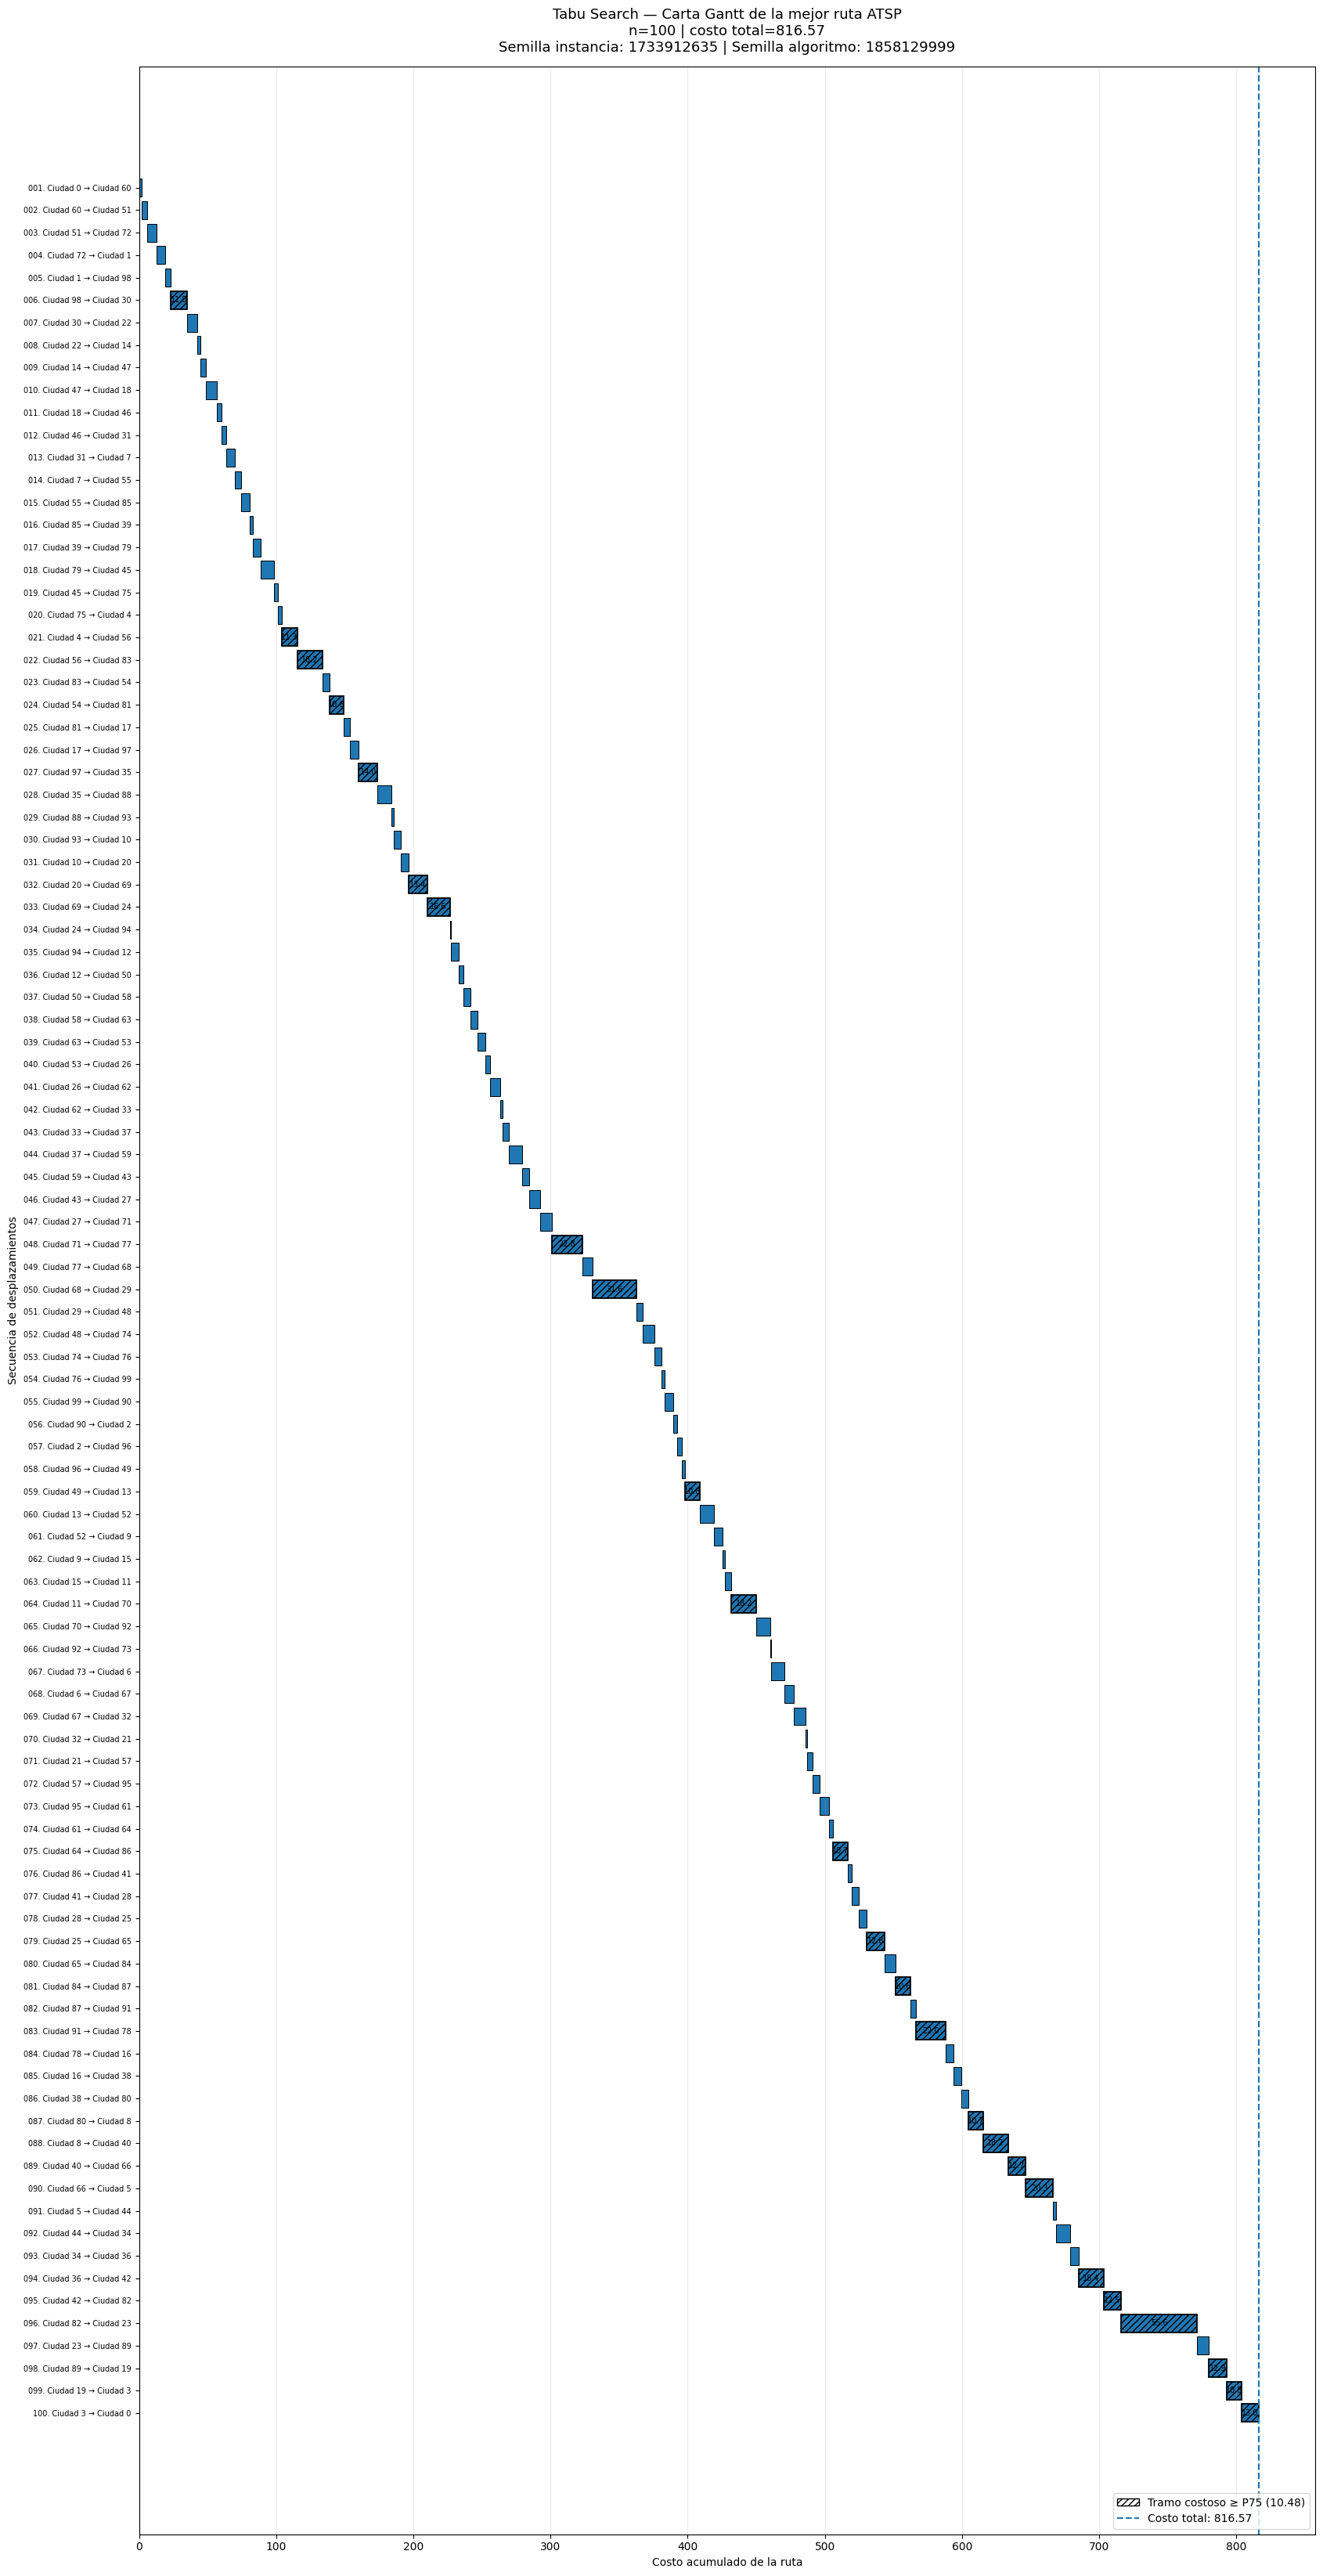

In [9]:
tabu_gantt = {}

for n in SIZES:

    coords, D = INSTANCES[n]
    mejor_ruta = tabu_solutions[n]

    print("\n" + "#" * 80)
    print(f"CARTA GANTT TABU SEARCH — n={n}")
    print(
        f"Semilla instancia: "
        f"{INSTANCE_SEEDS[n]}"
    )
    print(
        f"Semilla algoritmo: "
        f"{ALGORITHM_SEEDS[n]}"
    )

    df_gantt, fig, ax = crear_gantt_ruta(
        ruta=mejor_ruta,
        D=D,
        algoritmo="Tabu Search",
        n=n,
        semilla_instancia=INSTANCE_SEEDS[n],
        semilla_algoritmo=ALGORITHM_SEEDS[n],
        guardar=True,
        nombre_archivo=(
            f"gantt_tabu_search_n{n}_"
            f"instance_seed_{INSTANCE_SEEDS[n]}_"
            f"algorithm_seed_{ALGORITHM_SEEDS[n]}.png"
        ),
        mostrar_tabla=(n <= 20)
    )

    tabu_gantt[n] = df_gantt

    plt.show()